In [77]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [78]:
df = pd.read_csv(r'C:\Users\LENOVO\Flipkart-ETL-Pipeline\Data Cleaning ( Pandas )\Flipkart_cleaned_dataset.csv')

In [79]:
df = df.drop(columns='Unnamed: 0')

In [80]:
df.head(5)

,brand,model name,model color,storage,review,rating,star rating,ram,display_size,battery,discount
0,REDMI,REDMI 11 Prime 5G,Meadow Green,64 GB,262,4687,4.2,4 GB,6.58 inch,5000.0,No Discount
1,realme,realme GT 8 Pro,Diary White,512 GB,19,99,4.5,16 GB,6.79 inch,7000.0,9% off
2,OnePlus,OnePlus 11 5G,Eternal Green,256 GB,165,1900,4.5,16 GB,6.7 inch,5000.0,No Discount
3,IQOO,IQOO Z11 Lite 5G,Solar Flame,256 GB,0,0,0.0,6 GB,6.74 inch,6500.0,22% off
4,realme,realme P4R 5G,Silver Glare,128 GB,259,3219,4.4,6 GB,6.8 inch,8000.0,45% off


In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         96 non-null     str    
 1   model name    96 non-null     str    
 2   model color   96 non-null     str    
 3   storage       96 non-null     str    
 4   review        96 non-null     int64  
 5   rating        96 non-null     int64  
 6   star rating   96 non-null     float64
 7   ram           96 non-null     str    
 8   display_size  96 non-null     str    
 9   battery       94 non-null     float64
 10  discount      96 non-null     str    
dtypes: float64(2), int64(2), str(7)
memory usage: 14.4 KB


In [82]:
df.isnull().sum() 

brand           0
model name      0
model color     0
storage         0
review          0
rating          0
star rating     0
ram             0
display_size    0
battery         2
discount        0
dtype: int64

In [83]:
df[df['battery'].isnull()] # huh! Apple :/

,brand,model name,model color,storage,review,rating,star rating,ram,display_size,battery,discount
79,Apple,Apple iPhone 16e,White,256 GB,109,1434,4.5,256 GB ROM\r\n15.49 cm (6.1 inch) Super Retina...,6.1 inch,NaN,No Discount
82,Apple,Apple iPhone 16e,Black,256 GB,109,1434,4.5,256 GB ROM\r\n15.49 cm (6.1 inch) Super Retina...,6.1 inch,NaN,No Discount


In [84]:
df.duplicated().sum()

np.int64(38)

In [108]:
df['brand'].value_counts()

brand
realme      18
OPPO        15
vivo        13
OnePlus     12
REDMI       11
Samsung      7
IQOO         6
POCO         4
Motorola     3
Apple        2
Ai+          2
Google       1
11           1
Infinix      1
Name: count, dtype: int64

In [183]:
df.describe()

,review,rating,star rating,ram,battery,RAM_GB,Battery_mAh
count,96.000000,96.000000,96.000000,94.000000,94.000000,94.000000,94.000000
mean,414.427083,3954.718750,3.753125,7.914894,6398.872340,7.914894,6398.872340
std,693.713345,6965.884354,1.571386,3.264865,1145.558907,3.264865,1145.558907
min,0.000000,0.000000,0.000000,4.000000,4000.000000,4.000000,4000.000000
25%,27.250000,155.250000,4.200000,6.000000,5600.000000,6.000000,5600.000000
50%,192.000000,1972.500000,4.400000,8.000000,6500.000000,8.000000,6500.000000
75%,530.000000,4780.000000,4.500000,8.000000,7000.000000,8.000000,7000.000000
max,4568.000000,57433.000000,4.900000,16.000000,10001.000000,16.000000,10001.000000


## **EDA :**

### **1. Number of 5G brands on flipkart**

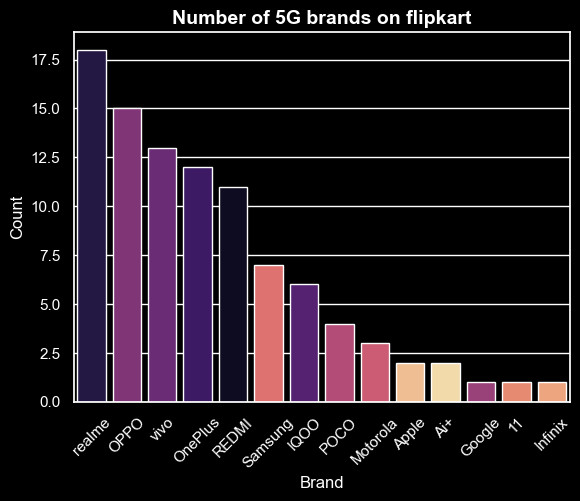

In [145]:
sns.set_theme(style="whitegrid")
plt.style.use('dark_background')

sns.countplot(data=df,x=df['brand'], order=df['brand'].value_counts().index, hue='brand', palette='magma')
plt.title('Number of 5G brands on flipkart',  fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.xlabel('Brand')
plt.ylabel('Count')
plt.show()

### **2. Rating of All Smartphones of Flipkart**

In [97]:
# Average Rating of every brand : 

# these are the top 3 brand with best ratings
df.groupby('brand')['star rating'].mean().sort_values(ascending=False)

brand
Google      4.500000
Apple       4.500000
OPPO        4.480000
Ai+         4.400000
realme      4.372222
REDMI       4.309091
Infinix     4.300000
Samsung     4.285714
POCO        4.175000
Motorola    4.000000
11          3.700000
vivo        3.538462
OnePlus     2.275000
IQOO        0.783333
Name: star rating, dtype: float64

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16576\3553418204.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='brand', y='star rating', palette='flare', errorbar=None)


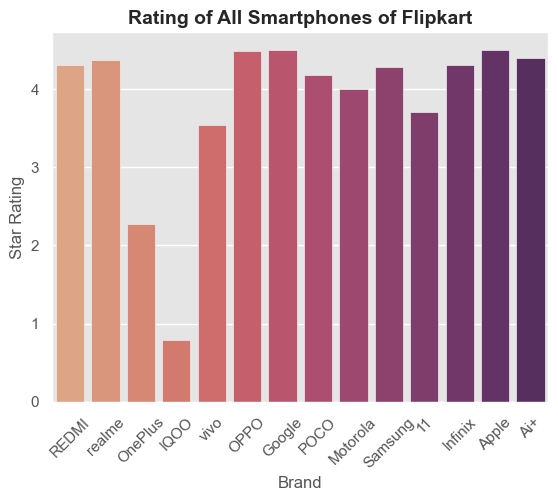

In [165]:

plt.xticks(rotation=45)
sns.barplot(data=df, x='brand', y='star rating', palette='flare', errorbar=None)
plt.title('Rating of All Smartphones of Flipkart',fontsize=14, fontweight='bold')
plt.xlabel('Brand')
plt.ylabel('Star Rating')
plt.style.use('bmh')
plt.show()

### **3. RAM vs Battery Capacity of 5G Phones**

In [90]:
df['ram'] = df['ram'].str.replace('GB', '')
df['ram'] = pd.to_numeric(df['ram'], errors='coerce')

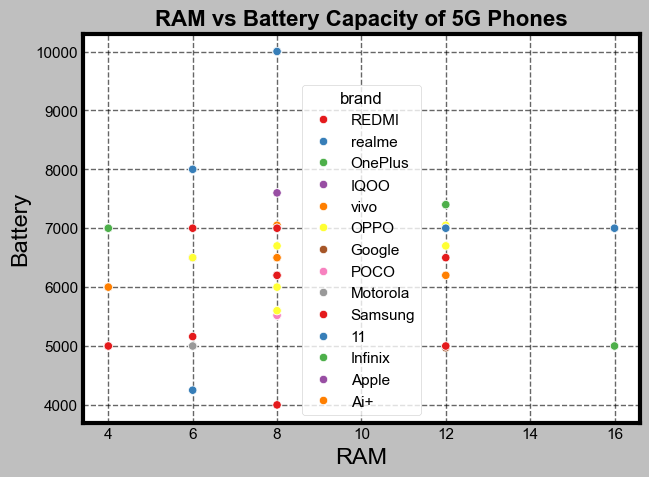

<Figure size 1700x600 with 0 Axes>

In [187]:
sns.scatterplot(data=df, x='ram', y='battery',palette='Set1',hue='brand',legend=True)
plt.title('RAM vs Battery Capacity of 5G Phones', fontweight='bold', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('RAM')
plt.ylabel('Battery')
plt.figure(figsize=(17, 6))
plt.style.use('grayscale')

plt.show()